# 04 — Modeling baselines and XGBoost

This notebook trained three scikit-learn-compatible models: logistic regression, random forest, and XGBoost. The models were compared using probability-based metrics because credit scoring depends on ranking and calibration.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from project_package.config import ensure_project_dirs, PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, TARGET
from project_package.plotting import save_figure
from project_package.reporting import save_table

ensure_project_dirs()
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

from project_package.features import create_modeling_split
from project_package.models import train_standard_models, predict_proba_positive, save_model
from project_package.evaluation import classification_metrics, metrics_frame
from project_package.plotting import plot_model_curves, plot_confusion

In [2]:
features_path = PROCESSED_DIR / "credit_default_features.csv"
if not features_path.exists():
    raise FileNotFoundError("Run Notebook 03 before this notebook.")
df = pd.read_csv(features_path)
X_train, X_test, y_train, y_test = create_modeling_split(df)
print(X_train.shape, X_test.shape)

(24000, 48) (6000, 48)


In [ ]:
#! pip install xgboost lightgbm catboost

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached narwhals-2.21.2-py3-none-any.whl.metadata (16 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 2.4 MB/s eta 0:00:42
    --------------------------------------- 1.8/101.7 MB 3.0 MB/s eta 0:00:33
    --------------------------------------- 2.1/101.7 MB 2.8 MB/s eta 0:00:36
    --------------------------------------- 2.1/101.7 MB 2.8 MB/s eta 0:00:36
    --------------------------------------- 2.1/101.7 MB 2.8 MB/s eta 0:00:36
    --------------------------------------- 2.1/101.7 MB 2.8 MB/s eta 0:00:36
    --------------------------------------- 2.1/101.7 MB 2.8 MB/s eta 0:00:36
   - -------------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Training standard models

The logistic model served as an interpretable baseline. The random forest and XGBoost models captured nonlinear interactions among repayment behavior, utilization, and demographic proxy variables.

In [3]:
trained_models = train_standard_models(X_train, y_train)
results = {}
prediction_table = pd.DataFrame({"y_true": y_test.reset_index(drop=True)})

for trained in trained_models:
    y_proba = predict_proba_positive(trained.pipeline, X_test)
    results[trained.name] = classification_metrics(y_test, y_proba, threshold=0.5)
    prediction_table[f"proba_{trained.name}"] = y_proba
    save_model(trained.pipeline, f"{trained.name}_pipeline.joblib")

comparison = metrics_frame(results)
save_table(comparison, "04_model_comparison_baselines_xgboost.csv")
prediction_table.to_csv(PROCESSED_DIR / "test_predictions_standard_models.csv", index=False)
comparison

,model,roc_auc,pr_auc,brier_score,log_loss,f1,precision,recall,balanced_accuracy,threshold
0,xgboost,0.781539,0.563667,0.179362,0.542408,0.535478,0.460412,0.639789,0.713432,0.5
1,random_forest,0.780983,0.559121,0.170180,0.520879,0.546571,0.499377,0.603617,0.715889,0.5
2,logistic_regression,0.760394,0.522432,0.188838,0.570214,0.510114,0.439303,0.608139,0.693862,0.5


## Model comparison plot

PR-AUC was emphasized because default was the minority class and precision-recall behavior mattered for risk triage.

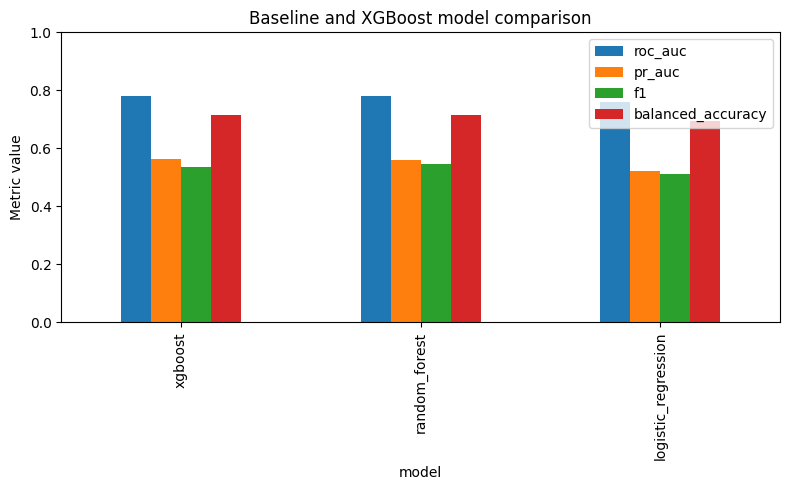

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison.set_index("model")[["roc_auc", "pr_auc", "f1", "balanced_accuracy"]].plot(kind="bar", ax=ax)
ax.set_title("Baseline and XGBoost model comparison")
ax.set_ylabel("Metric value")
ax.set_ylim(0, 1)
save_figure(fig, "04_baseline_xgboost_model_comparison.png")
plt.show()

## Curves for the best standard model

The best model by PR-AUC was selected for initial diagnostic plots.

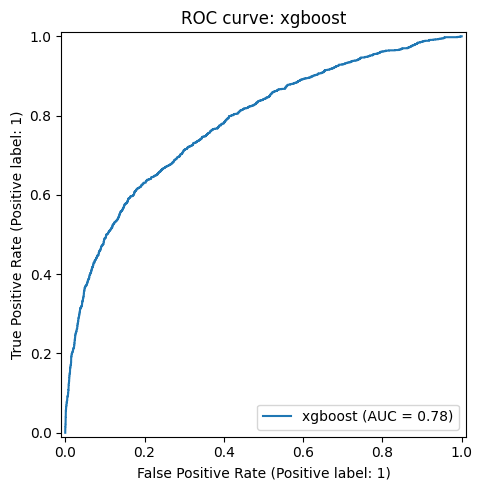

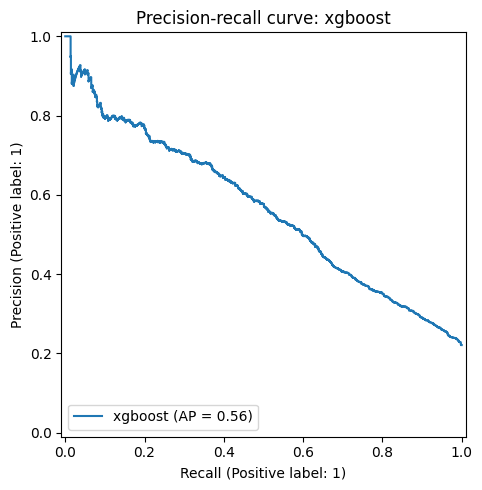

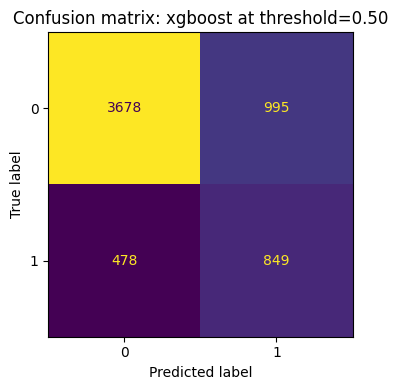

In [5]:
best_name = comparison.iloc[0]["model"]
best_model = {m.name: m.pipeline for m in trained_models}[best_name]
best_proba = prediction_table[f"proba_{best_name}"].values
fig_roc, fig_pr = plot_model_curves(y_test, best_proba, best_name)
save_figure(fig_roc, f"04_roc_curve_{best_name}.png")
save_figure(fig_pr, f"04_precision_recall_curve_{best_name}.png")
plt.show()

fig_cm = plot_confusion(y_test, best_proba, threshold=0.5, model_name=best_name)
save_figure(fig_cm, f"04_confusion_matrix_{best_name}.png")
plt.show()

## Saving split data

The test split was saved so that calibration, fairness, and reporting notebooks evaluated the same holdout cases.

In [6]:
X_train.assign(**{TARGET: y_train.values}).to_csv(PROCESSED_DIR / "train_split.csv", index=False)
X_test.assign(**{TARGET: y_test.values}).to_csv(PROCESSED_DIR / "test_split.csv", index=False)
print("Saved train/test splits and model predictions.")

Saved train/test splits and model predictions.
